In [ ]:
import pandas as pd
import numpy as np
import re
def calc_rate(guesses:list[int]):
    ids = [idx+1 for idx, i in enumerate(guesses)]
    cs = np.cumsum(guesses)
    return cs/ids

def find_win(l:list):
    """ if last 10 were correct"""
    if np.mean(l[-10:]) == 1:
        return "Win"
    else: 
        return "Lose"

def count_turns(l:list):
    "how many responses were given in a game"
    return len(l)

def count_wins(l:list):
    "count correct responses"
    return len([i for i in l if i == 1])

def total_time(l:list):
    "last wall_time - first wall_time"
    return float(l[-1]) - float(l[0])

In [257]:
#plot human rates
#human data
a_df = pd.read_csv("../data/AlienData.csv", dtype="object")
rule_ids = pd.read_csv("../data/rule_ids.csv", dtype = "object")
#turn cols to float
a_df["points"] = [float(i) for i  in a_df["points"]]
a_df["correct"] = [float(i) for i  in a_df["correct"]]
# keep only the test
a_df = a_df[a_df["block"] == "test"]
#47+(90/2)+(88/2) = 136
#There should be 136 total games in the test phase
#differentiate IDS
a_df["trial_id"] = a_df["rule_num"] + "_" + a_df["trial"]
a_df["game_id"] = a_df["unique_id"] + "_" + a_df["rule_num"]
a_df["full_id"] = a_df["unique_id"] + "_" + a_df["trial_id"]
#select important columns
a_df_small = a_df[["unique_id","game_id","full_id","stimulus","choice","correct","rule_num","rule_id","wall_time"]]
#pivot the dataframe to have all games in 1 row
id_list = []
stim_list = []
choice_list= []
correct_list = []
rule_id_list = []
rule_num_list = []
wall_time_list = []

#separate by games
for u_id in sorted(list(set(a_df_small["game_id"]))):
    #select subset
    subs = a_df_small[a_df_small["game_id"] == u_id]
    #collect vals
    id_list.append(u_id)
    stim_list.append(list(subs["stimulus"]))
    choice_list.append(list(subs["choice"]))
    correct_list.append(list(subs["correct"]))
    rule_id_list.append(list(subs["rule_id"]))
    rule_num_list.append(list(subs["rule_num"]))
    wall_time_list.append(list(subs["wall_time"]))

#new frame
n_df = pd.DataFrame({"game_id":id_list,
                     "stims":stim_list,
                     "choices":choice_list,
                     "correct":correct_list,
                     "rule_id":rule_id_list,
                     "rule_num":rule_num_list,
                     "wall_time":wall_time_list})

#derive important values
n_df["win"] = n_df["correct"].map(find_win)
n_df["n_turns"] = n_df["correct"].map(count_turns)
n_df["n_correct"] = n_df["correct"].map(count_wins)
n_df["tt"] = n_df["wall_time"].map(total_time)
#add session ids
n_df = a_df[["game_id","unique_id","condition"]].drop_duplicates().merge(n_df,on="game_id")


#filter out last games which did not finish because time ran out
ids = list(set(n_df["unique_id"]))
last_g_ids = []
for i in ids:
    #separate sessions
    subs = n_df[n_df["unique_id"]==i]
    #separate games
    #max(last num after last _ in game_id)
    lc = np.max([int(re.findall(r"(\d+)[^_]*$",c)[0]) for c in list(subs["game_id"])])
    #lc = np.max([int(c[-1]) for c in list(subs["game_id"])])
    last_g_id = f"{i}_{lc}"
    last_g_ids.append(last_g_id)

#either not a last game, or a last game with win or a last game with tt over 400
full_df = n_df[(~n_df['game_id'].isin(last_g_ids)) | ((n_df['game_id'].isin(last_g_ids)) & (n_df["win"]=="Win")) | ((n_df['game_id'].isin(last_g_ids)) & (n_df["tt"]>=400))]

#nans (probably timeouts) to 0, technically they were "wrong answers"
def float_int_na_0(l:list):
    return [int(i) if i in [1,0] else 0 for i in l]
full_df["correct"] = full_df["correct"].map(float_int_na_0)

#check correct game evaluation
def rolling_c(cs:list,n_c:int=10)->int:
    """counts the occurrence of n_c 1s in a row in a list"""
    i_counter = 0
    meta_i_counter = 0
    for idx_i,i in enumerate(cs):
        if i == 1:
            i_counter += 1
        else:
            i_counter=0
        
        if i_counter == n_c:
            meta_i_counter +=1
            i_counter = 0
    return meta_i_counter

full_df["insp"] = full_df["correct"].map(rolling_c)
#full_df[full_df["insp"]==2]
# ONE game where it happened 2X

In [230]:
import pymc as pm
import arviz as az
import nutpie
import matplotlib.pyplot as plt

In [260]:
full_df.head(1)

,game_id,unique_id,condition,stims,choices,correct,rule_id,rule_num,wall_time,win,n_turns,n_correct,tt,insp
0,1_10_2_2,1_10_2,1_I,"[00110, 10110, 10101, 00000, 01110, 10100, 111...","[ignore, kill, ignore, ignore, kill, ignore, k...","[0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, ...","[05, 05, 05, 05, 05, 05, 05, 05, 05, 05, 05, 0...","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[907.57380958, 911.136457293, 918.621201429, 9...",Lose,68,32,417.182558,0


In [271]:
cond_index, cond_unique = pd.factorize(full_df["condition"])
win_index, win_unique = pd.factorize(full_df["win"])

n_correct = np.array([i for i in full_df["n_correct"]])
max_turns = np.array([i for i in full_df["n_turns"]])

#model it
comp_model = pm.Model(coords = {"condition":cond_unique,
                                "win":win_unique})

with comp_model:
    #prior probability of getting n_correct ot of max
    p_a = pm.Beta("p_a",1,1,dims=("condition","win"))
    

    # Likelihood (sampling distribution) of observations 
    n_turns = pm.NegativeBinomial("max_turns", 
                      n= n_correct,
                      p= p_a[(cond_index,win_index)], 
                      observed = max_turns
                        )
               
#run inference
compiled_model = nutpie.compile_pymc_model(comp_model)
ests = nutpie.sample(compiled_model,chains=4,draws=1000,seed=1,progress_bar=True)
with comp_model:
        ests = pm.sample_posterior_predictive(ests,
                progressbar=True,
                random_seed=1,
                extend_inferencedata=True)

az.summary(ests)
#az.plot_ppc(ests)
#plt.show()

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1400,0,0.85,3
,1400,0,0.87,3
,1400,0,0.89,3
,1400,0,0.94,3


Sampling: [max_turns]


Output()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"p_a_logodds__[0, 0]",-0.548,0.022,-0.588,-0.505,0.0,0.000,6251.0,3697.0,1.0
"p_a_logodds__[0, 1]",-0.378,0.019,-0.414,-0.343,0.0,0.000,6680.0,3443.0,1.0
"p_a_logodds__[1, 0]",-0.539,0.027,-0.591,-0.491,0.0,0.000,6646.0,3184.0,1.0
"p_a_logodds__[1, 1]",-0.351,0.031,-0.411,-0.294,0.0,0.000,7007.0,3251.0,1.0
"p_a_logodds__[2, 0]",-0.543,0.030,-0.599,-0.487,0.0,0.001,7034.0,2680.0,1.0
"p_a_logodds__[2, 1]",-0.339,0.028,-0.394,-0.289,0.0,0.000,5990.0,3359.0,1.0
"p_a[1_I, Lose]",0.366,0.005,0.357,0.376,0.0,0.000,6251.0,3697.0,1.0
"p_a[1_I, Win]",0.407,0.005,0.398,0.415,0.0,0.000,6680.0,3443.0,1.0
"p_a[2_ND, Lose]",0.368,0.006,0.356,0.380,0.0,0.000,6646.0,3184.0,1.0
"p_a[2_ND, Win]",0.413,0.008,0.399,0.427,0.0,0.000,7007.0,3251.0,1.0


<Axes: xlabel='max_turns'>

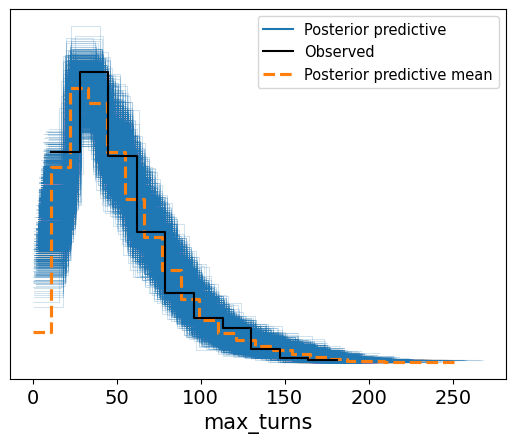

In [269]:
az.plot_ppc(ests)

In [ ]:
cond_index, cond_unique = pd.factorize(full_df["condition"])
win_index, win_unique = pd.factorize(full_df["win"])
session_index, session_unique = pd.factorize(full_df["unique_id"])

n_correct = np.array([i for i in full_df["n_correct"]])
max_turns = np.array([i for i in full_df["n_turns"]])

#model it
comp_model = pm.Model(coords = {"condition":cond_unique,
                                "win":win_unique})

with comp_model:
    #prior human probability of getting n_correct ot of max
    p_human = pm.Beta("p_human",1,1)
    effect_w = pm.Normal("effect_w",0,0.1,dims=("win"))
    effect_cond = pm.Normal("effect_cond",0,0.1,dims=("condition"))

    # Likelihood (sampling distribution) of observations 
    n_turns = pm.NegativeBinomial("max_turns", 
                      n= n_correct,
                      p= p_human + effect_w[win_index] + effect_cond[cond_index], 
                      observed = max_turns
                        )
               
#run inference
compiled_model = nutpie.compile_pymc_model(comp_model)
ests = nutpie.sample(compiled_model,chains=4,draws=1000,seed=1,progress_bar=True)
with comp_model:
        ests = pm.sample_posterior_predictive(ests,
                progressbar=True,
                random_seed=1,
                extend_inferencedata=True)

az.summary(ests)
#az.plot_ppc(ests)
#plt.show()

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1400,0,0.16,127
,1400,0,0.15,7
,1400,0,0.16,127
,1400,0,0.14,7


Sampling: [max_turns]


Output()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p_human_logodds__,-0.467,0.397,-1.223,0.243,0.015,0.011,729.0,761.0,1.01
effect_w[Lose],-0.022,0.071,-0.146,0.116,0.002,0.002,868.0,1068.0,1.01
effect_w[Win],0.022,0.071,-0.104,0.156,0.002,0.002,867.0,1053.0,1.01
effect_cond[1_I],-0.003,0.059,-0.112,0.107,0.002,0.002,949.0,887.0,1.00
effect_cond[2_ND],0.001,0.059,-0.107,0.114,0.002,0.002,948.0,805.0,1.00
effect_cond[3_D],0.002,0.059,-0.105,0.116,0.002,0.002,944.0,860.0,1.00
p_human,0.389,0.090,0.212,0.543,0.003,0.002,729.0,761.0,1.01


<Axes: xlabel='max_turns'>

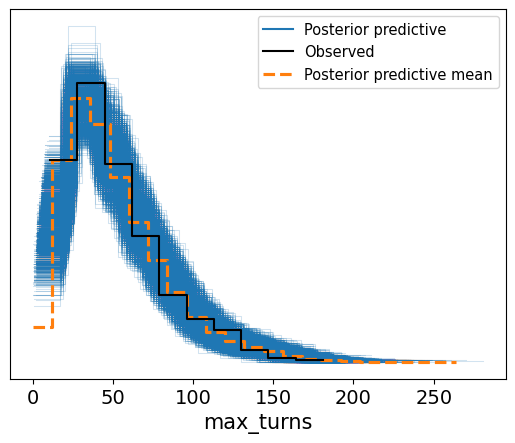

In [287]:
az.plot_ppc(ests)

In [276]:
from plotnine import *

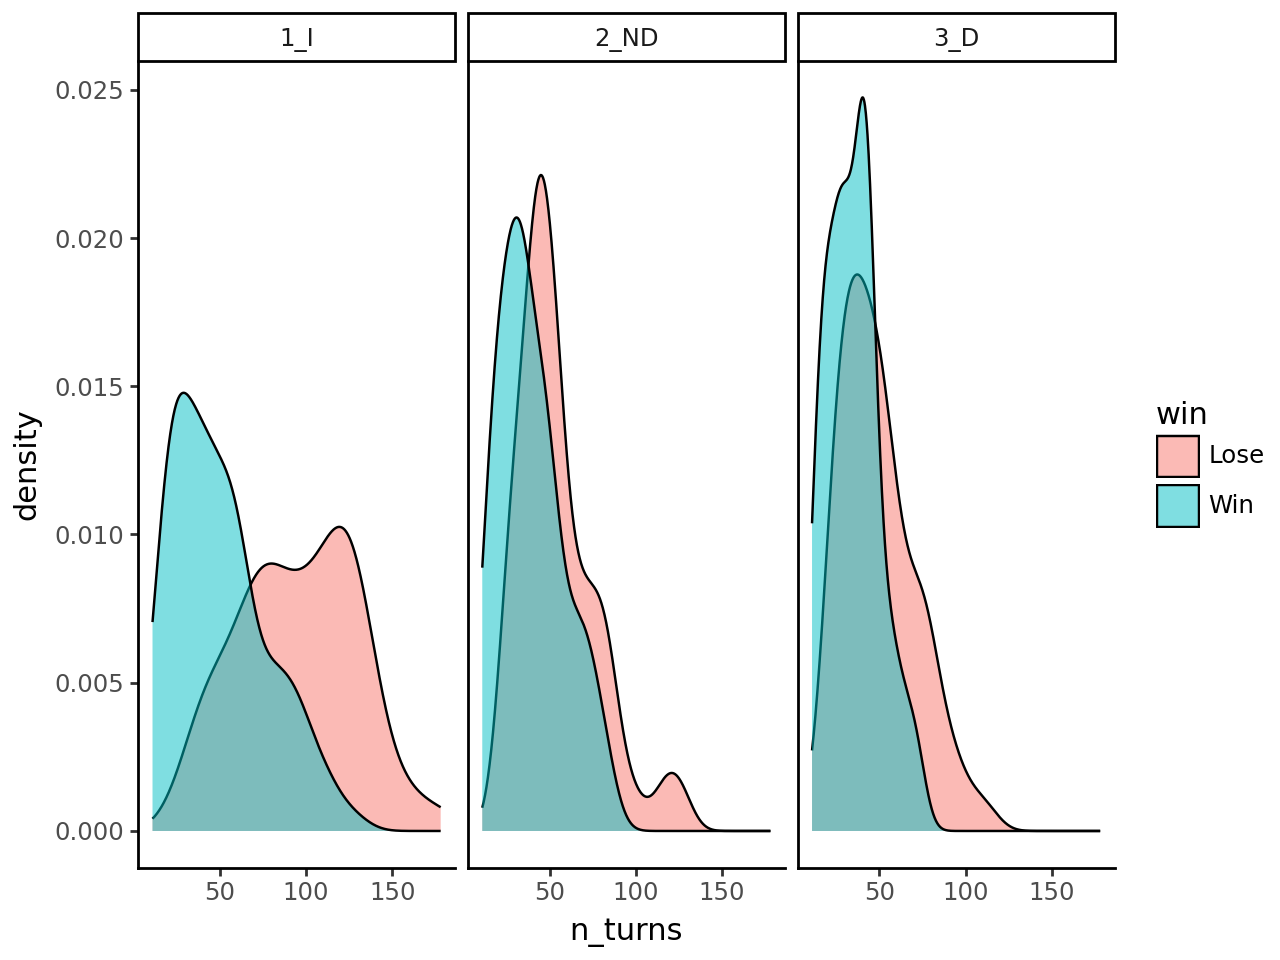

In [285]:
(ggplot(full_df,aes("n_turns", group="win",fill="win"))
        +geom_density(alpha= 0.5)
        +theme_classic()
        +facet_wrap("condition")

)

In [ ]:
cond_index, cond_unique = pd.factorize(full_df["condition"])
win_index, win_unique = pd.factorize(full_df["win"])

n_correct = np.array([i for i in full_df["n_correct"]])
max_turns = np.array([i for i in full_df["n_turns"]])

#model it
comp_model = pm.Model(coords = {"condition":cond_unique,
                                "win":win_unique})

with comp_model:
    
    #prior human beta
    human_alpha = pm.Uniform("H_a",1,10)
    human_beta = pm.Uniform("H_b",1,10)
    #
    #draw for win/loss from human possible values
    p_wl = pm.Beta("p_wl",human_alpha,human_beta,
                   dims=("condition","win"))
    # Likelihood (sampling distribution) of observations 
    n_turns = pm.NegativeBinomial("max_turns", 
                      n= n_correct,
                      p= p_wl[(cond_index,win_index)], 
                      observed = max_turns
                        )
               
#run inference
compiled_model = nutpie.compile_pymc_model(comp_model)
ests = nutpie.sample(compiled_model,chains=4,draws=1000,seed=1,progress_bar=True)
with comp_model:
        ests = pm.sample_posterior_predictive(ests,
                progressbar=True,
                random_seed=1,
                extend_inferencedata=True)

az.summary(ests)
#az.plot_ppc(ests)
#plt.show()

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1400,0,0.56,7
,1400,0,0.63,7
,1400,0,0.62,7
,1400,0,0.69,7


Sampling: [max_turns]


Output()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
H_a_interval__,0.187,0.784,-1.441,1.541,0.015,0.019,3033.0,2387.0,1.0
H_b_interval__,1.790,1.342,-0.582,4.326,0.026,0.030,2821.0,2363.0,1.0
"p_wl_logodds__[0, 0]",-0.547,0.023,-0.590,-0.505,0.000,0.000,5918.0,2750.0,1.0
"p_wl_logodds__[0, 1]",-0.378,0.019,-0.413,-0.343,0.000,0.000,6801.0,2610.0,1.0
"p_wl_logodds__[1, 0]",-0.539,0.027,-0.590,-0.489,0.000,0.000,5910.0,2744.0,1.0
"p_wl_logodds__[1, 1]",-0.351,0.030,-0.407,-0.296,0.000,0.001,6208.0,2988.0,1.0
"p_wl_logodds__[2, 0]",-0.542,0.029,-0.595,-0.486,0.000,0.000,5524.0,2857.0,1.0
"p_wl_logodds__[2, 1]",-0.339,0.028,-0.392,-0.289,0.000,0.000,6512.0,3085.0,1.0
H_a,5.858,1.471,3.169,8.797,0.027,0.023,3033.0,2387.0,1.0
H_b,8.181,1.471,5.443,10.000,0.027,0.027,2821.0,2363.0,1.0


<Axes: xlabel='max_turns'>

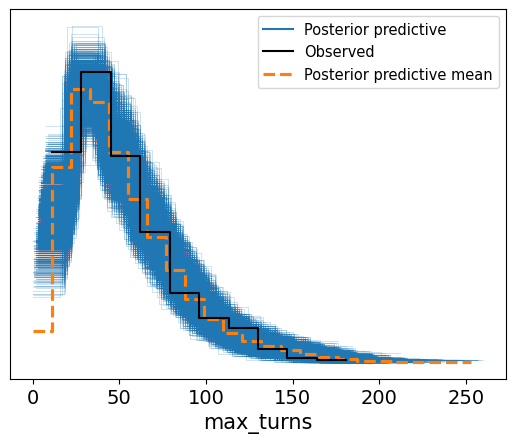

In [308]:
az.plot_ppc(ests)

In [ ]:
pm.LogitNormal

In [377]:
def calc_point_rate(l:list):
    pointrate = np.mean(l)
    if pointrate == 1:
        pointrate = 0.999

    return pointrate

full_df["point_rate"] = full_df["correct"].map(calc_point_rate)

In [454]:
#cond_index, cond_unique = pd.factorize(full_df["condition"])
win_index, win_unique = pd.factorize(full_df["win"])
session_index, session_unique = pd.factorize(full_df["unique_id"])
game_index, game_unique = pd.factorize(full_df["game_id"])

n_correct = np.array([i for i in full_df["n_correct"]])
max_turns = np.array([i for i in full_df["n_turns"]])
pointrate = np.array([i for i in full_df["point_rate"]])

#model it
comp_model = pm.Model(coords = {"session":session_unique,
                                "win":win_unique,
                                "game":game_unique})

with comp_model:
   #prior human probability of getting n_correct ot of max
    human_alpha = pm.Uniform("h_a",1,30,dims=("win"))
    human_beta = pm.Uniform("h_b",1,30,dims=("win"))
    #p_human = pm.Beta("p_human",1,1)
    #effect_w = pm.Normal("effect_w",0,0.1,dims=("win"))
    #effect_cond = pm.Normal("effect_cond",0,0.1,dims=("condition"))

    # Likelihood (sampling distribution) of observations 
    p_rate = pm.Beta("rate", 
                      alpha=human_alpha[win_index],
                      beta=human_beta[win_index], 
                      observed = pointrate
                        )
               
#run inference
compiled_model = nutpie.compile_pymc_model(comp_model)
ests = nutpie.sample(compiled_model,chains=4,draws=1000,seed=1,progress_bar=True)
with comp_model:
        ests = pm.sample_posterior_predictive(ests,
                progressbar=True,
                random_seed=1,
                extend_inferencedata=True)

az.summary(ests)
#az.plot_ppc(ests)
#plt.show()

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1400,0,0.52,31
,1400,0,0.53,23
,1400,0,0.52,7
,1400,0,0.48,11


Sampling: [rate]


Output()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
h_a_interval__[0],0.102,0.243,-0.321,0.562,0.007,0.008,1333.0,1305.0,1.0
h_a_interval__[1],-0.464,0.148,-0.730,-0.170,0.004,0.003,1754.0,2011.0,1.0
h_b_interval__[0],-0.504,0.186,-0.850,-0.168,0.005,0.005,1350.0,1365.0,1.0
h_b_interval__[1],-1.884,0.117,-2.097,-1.662,0.003,0.002,1762.0,1787.0,1.0
h_a[Lose],16.222,1.722,13.233,19.513,0.048,0.047,1333.0,1305.0,1.0
h_a[Win],12.215,1.017,10.432,14.270,0.024,0.019,1754.0,2011.0,1.0
h_b[Lose],11.950,1.262,9.683,14.282,0.035,0.033,1350.0,1365.0,1.0
h_b[Win],4.841,0.388,4.173,5.624,0.009,0.007,1762.0,1787.0,1.0


<Axes: xlabel='rate'>

c:\alien_filter\alien_venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
c:\alien_filter\alien_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.


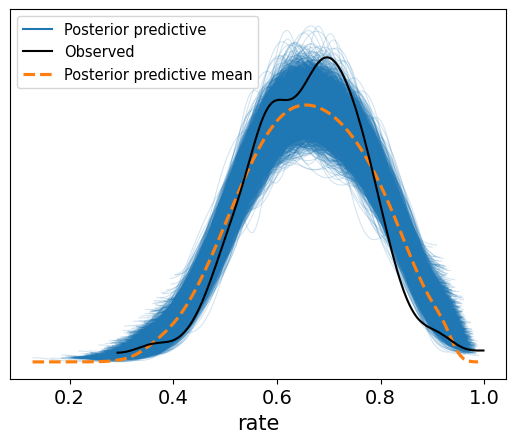

In [455]:
az.plot_ppc(ests)

In [478]:
cond_index, cond_unique = pd.factorize(full_df["condition"])
win_index, win_unique = pd.factorize(full_df["win"])
session_index, session_unique = pd.factorize(full_df["unique_id"])
game_index, game_unique = pd.factorize(full_df["game_id"])

n_correct = np.array([i for i in full_df["n_correct"]])
max_turns = np.array([i for i in full_df["n_turns"]])
pointrate = np.array([i for i in full_df["point_rate"]])
c = [i for i in full_df["correct"]]

#model it
comp_model = pm.Model(coords = {"session":session_unique,
                                "condition":cond_unique,
                                "win":win_unique,
                                "game":game_unique})

with comp_model:
   #prior human probability of getting n_correct ot of max
    human_alpha = pm.Uniform("h_a",1,30,dims=("win","condition"))
    human_beta = pm.Uniform("h_b",1,30,dims=("win","condition"))
    #p_human = pm.Beta("p_human",1,1)
    #effect_w = pm.Normal("effect_w",0,0.1,dims=("win"))
    #effect_cond = pm.Normal("effect_cond",0,0.1,dims=("condition"))

    # Likelihood (sampling distribution) of observations 
    p_rate = pm.Beta("rate", 
                      alpha=human_alpha[(win_index,cond_index)],
                      beta=human_beta[(win_index,cond_index)], 
                      observed = pointrate
                        )
               
#run inference
compiled_model = nutpie.compile_pymc_model(comp_model)
ests = nutpie.sample(compiled_model,chains=4,draws=1000,seed=1,progress_bar=True)
with comp_model:
        ests = pm.sample_posterior_predictive(ests,
                progressbar=True,
                random_seed=1,
                extend_inferencedata=True)

az.summary(ests)
#az.plot_ppc(ests)
#plt.show()

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1400,0,0.34,31
,1400,0,0.38,23
,1400,0,0.37,19
,1400,0,0.37,15


Sampling: [rate]


Output()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"h_a_interval__[0, 0]",0.466,0.557,-0.485,1.526,0.012,0.016,2708.0,1755.0,1.0
"h_a_interval__[0, 1]",-0.021,0.359,-0.711,0.638,0.006,0.007,3428.0,2535.0,1.0
"h_a_interval__[0, 2]",0.184,0.424,-0.549,0.958,0.008,0.012,3230.0,2478.0,1.0
"h_a_interval__[1, 0]",-0.401,0.221,-0.829,-0.005,0.003,0.004,4626.0,2635.0,1.0
"h_a_interval__[1, 1]",0.421,0.535,-0.578,1.321,0.011,0.018,3260.0,1970.0,1.0
"h_a_interval__[1, 2]",-0.739,0.241,-1.193,-0.288,0.004,0.004,4732.0,2742.0,1.0
"h_b_interval__[0, 0]",-0.263,0.359,-0.983,0.386,0.007,0.007,2712.0,1791.0,1.0
"h_b_interval__[0, 1]",-0.627,0.276,-1.138,-0.103,0.005,0.005,3513.0,2708.0,1.0
"h_b_interval__[0, 2]",-0.427,0.311,-0.996,0.154,0.005,0.006,3294.0,2568.0,1.0
"h_b_interval__[1, 0]",-1.789,0.172,-2.113,-1.477,0.003,0.003,4682.0,2832.0,1.0


<Axes: xlabel='rate'>

c:\alien_filter\alien_venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
c:\alien_filter\alien_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.


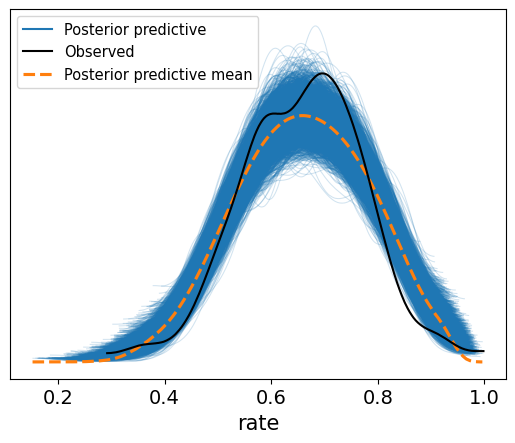

In [479]:
az.plot_ppc(ests)

In [ ]:
with pm.Model(coords=coords) as hierarchical_intercept:
    # Priors
    sigma_a = pm.HalfCauchy("sigma_a", 5)

    # County uranium model
    gamma_0 = pm.Normal("gamma_0", mu=0.0, sigma=10.0)
    gamma_1 = pm.Normal("gamma_1", mu=0.0, sigma=10.0)

    # Uranium model for intercept
    mu_a = pm.Deterministic("mu_a", gamma_0 + gamma_1 * u)
    # County variation not explained by uranium
    epsilon_a = pm.Normal("epsilon_a", mu=0, sigma=1, dims="county")
    alpha = pm.Deterministic("alpha", mu_a + sigma_a * epsilon_a, dims="county")

    # Common slope
    beta = pm.Normal("beta", mu=0.0, sigma=10.0)

    # Model error
    sigma_y = pm.Uniform("sigma_y", lower=0, upper=100)

    # Expected value
    y_hat = alpha[county] + beta * floor_measure

    # Data likelihood
    y_like = pm.Normal("y_like", mu=y_hat, sigma=sigma_y, observed=log_radon)

In [ ]:
"""
                latency ~ 0 + Language:Task + (1|Pair) ,
                sigma ~ 0 + Language:Task + (1|Pair),
                #sigma ~ 1, # in the simulations sigma was not varied to keep it simple
                beta ~ 0 + Language:Task + (1|Pair)
                #beta ~  (1|Pair)# beta was also not dependent on condition
"""

<Axes: xlabel='rate'>

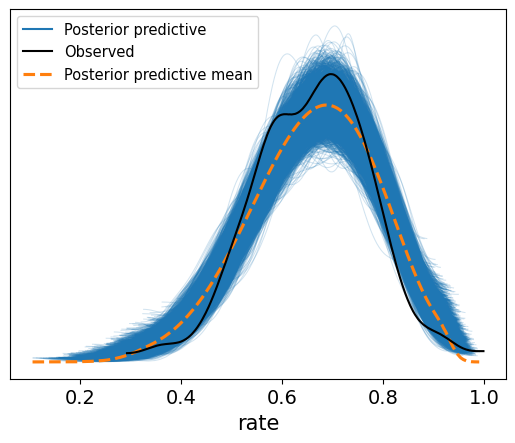

In [ ]:
cond_index, cond_unique = pd.factorize(full_df["condition"])
win_index, win_unique = pd.factorize(full_df["win"])
session_index, session_unique = pd.factorize(full_df["unique_id"])
game_index, game_unique = pd.factorize(full_df["game_id"])

n_correct = np.array([i for i in full_df["n_correct"]])
max_turns = np.array([i for i in full_df["n_turns"]])
pointrate = np.array([i for i in full_df["point_rate"]])
c = [i for i in full_df["correct"]]

#model it
comp_model = pm.Model(coords = {"session":session_unique,
                                "condition":cond_unique,
                                "win":win_unique,
                                "game":game_unique})

with comp_model:
    win_idx = pm.Data("win_idx", win_unique, dims="game")
    condition_idx = pm.Data("condition_idx", cond_unique, dims="game")
   #prior human probability of getting n_correct ot of max
    # Priors
    mu_a = pm.Normal("mu_a", mu=0.0, sigma=10.0)
    sigma_a = pm.Exponential("sigma_a", 1)

    mu_b = pm.Normal("mu_b", mu=0.0, sigma=10.0)
    sigma_b = pm.Exponential("sigma_b", 1)

    # Random intercepts
    alpha = pm.Normal("alpha", mu=mu_a, sigma=sigma_a, dims="cond")
    # Random slopes
    beta = pm.Normal("beta", mu=mu_b, sigma=sigma_b, dims="county")

    # Model error
    sigma_y = pm.Exponential("sigma_y", 1)

    # Expected value
    y_hat = alpha[win_idx] + beta[win_idx] * condition_idx
    # Data likelihood
    y_like = pm.Normal("y_like", mu=y_hat, sigma=sigma_y, observed=log_radon, dims="obs_id")

    # Likelihood (sampling distribution) of observations 
    p_rate = pm.Beta("rate", 
                      alpha=human_alpha[(win_index,cond_index)],
                      beta=human_beta[(win_index,cond_index)], 
                      observed = pointrate
                        )
               
#run inference
compiled_model = nutpie.compile_pymc_model(comp_model)
ests = nutpie.sample(compiled_model,chains=4,draws=1000,seed=1,progress_bar=True)
with comp_model:
        ests = pm.sample_posterior_predictive(ests,
                progressbar=True,
                random_seed=1,
                extend_inferencedata=True)

az.summary(ests)
#az.plot_ppc(ests)
#plt.show()

In [452]:
len_n = 10000
vals_1 = pm.draw(pm.Beta.dist(mu=0.5,sigma=0.3),len_n)
vals_2 = pm.draw(pm.Beta.dist(mu=0.6,sigma=0.4),len_n)
a = pd.DataFrame({"name":["v1" for i in range(len_n)] + ["v2" for i in range(len_n)],
              "val": list(vals_1) +list(vals_2)})

In [ ]:
pm.BetaBinomial.dist()

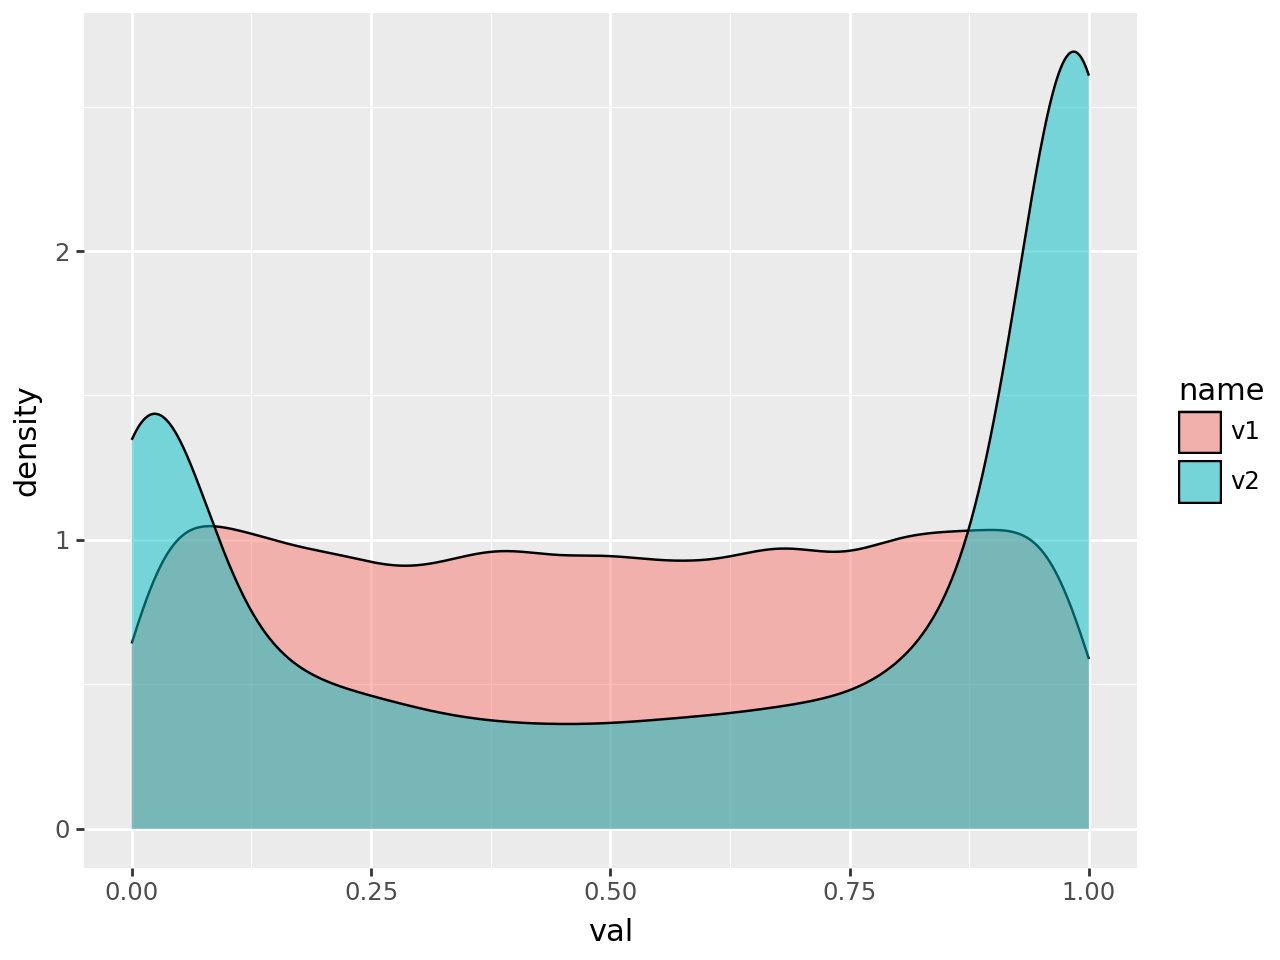

In [453]:
(
    ggplot(a,aes("val",fill = "name"))
    + geom_density(alpha=.5)
)